In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from multiprocessing import Pool, cpu_count
from functools import partial

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True

## Load Hourly Consumption Data

In [ ]:
xlsx_path = "20251111_JUNCTION_training.xlsx"

# Load hourly consumption data (no resampling)
df_cons = pd.read_excel(xlsx_path, sheet_name="training_consumption")
df_cons["measured_at"] = pd.to_datetime(df_cons["measured_at"])
df_cons = df_cons.sort_values("measured_at").set_index("measured_at")

print("Hourly consumption shape:", df_cons.shape)
print("Number of groups:", len(df_cons.columns))
print("Date range:", df_cons.index.min(), "to", df_cons.index.max())
print("\nFirst few rows:")
print(df_cons.head())

Hourly consumption shape: (32856, 112)
Number of groups: 112
Date range: 2021-01-01 00:00:00+00:00 to 2024-09-30 23:00:00+00:00

First few rows:
                                28        29        30        36        37   \
measured_at                                                                   
2021-01-01 00:00:00+00:00  7.010736  0.198555  1.192911  0.673303  0.170359   
2021-01-01 01:00:00+00:00  6.600845  0.189258  1.108660  0.641161  0.158715   
2021-01-01 02:00:00+00:00  6.468329  0.188044  1.088216  0.651150  0.153970   
2021-01-01 03:00:00+00:00  6.712097  0.188575  1.142844  0.659185  0.150787   
2021-01-01 04:00:00+00:00  6.418159  0.196142  1.163408  0.683347  0.161964   

                                38        39        40        41        42   \
measured_at                                                                   
2021-01-01 00:00:00+00:00  0.696948  0.147846  0.162057  0.755435  0.159639   
2021-01-01 01:00:00+00:00  0.653563  0.135761  0.149332  0.70749

## Load Group Metadata

In [ ]:
groups_df = pd.read_excel(xlsx_path, sheet_name="groups")
groups_df["group_id"] = groups_df["group_id"].astype(str)

meta_cols = [c for c in groups_df.columns if c != "group_id"]

def describe_group_row(row):
    parts = []
    for col in meta_cols:
        val = row[col]
        if pd.notna(val):
            parts.append(str(val))
    return " / ".join(parts)

group_desc = (
    groups_df
    .set_index("group_id")
    .apply(describe_group_row, axis=1)
    .to_dict()
)

## Load Exogenous Variables (Hourly)

For 2-day ahead forecasting, we use hourly exogenous variables:
- Electricity price (EUR/MWh)
- Heating demand

In [ ]:
# 1. Hourly prices
df_prices = pd.read_excel(xlsx_path, sheet_name="training_prices")
df_prices["measured_at"] = pd.to_datetime(df_prices["measured_at"])
df_prices = df_prices.sort_values("measured_at").set_index("measured_at")
hourly_price = df_prices["eur_per_mwh"].astype(float)

# 2. Hourly heating demand
df_temp = pd.read_excel(xlsx_path, sheet_name="training_data_2021_2024")
df_temp["measured_at"] = pd.to_datetime(df_temp["measured_at"])
df_temp = df_temp.sort_values("measured_at").set_index("measured_at")
hourly_heating = df_temp["heating_demand"].astype(float)

# Combine all exogenous variables into one DataFrame
exog_vars = pd.concat([hourly_price, hourly_heating], axis=1, join="inner")
exog_vars.columns = ["price", "heating_demand"]

print("Exogenous variables shape:", exog_vars.shape)
print("Exogenous variables:")
print(exog_vars.head())
print(f"\nDate range: {exog_vars.index.min()} to {exog_vars.index.max()}")

Exogenous variables shape: (32856, 2)
Exogenous variables:
                           price  heating_demand
measured_at                                     
2021-01-01 00:00:00+00:00  24.35            18.3
2021-01-01 01:00:00+00:00  23.98            18.6
2021-01-01 02:00:00+00:00  23.72            18.2
2021-01-01 03:00:00+00:00  23.73            18.3
2021-01-01 04:00:00+00:00  24.06            18.3

Date range: 2021-01-01 00:00:00+00:00 to 2024-09-30 23:00:00+00:00


## Define Metrics and Helper Functions

In [ ]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def compute_metrics(y_true, y_pred, label_prefix=""):
    return {
        f"{label_prefix}MAE": mean_absolute_error(y_true, y_pred),
        f"{label_prefix}RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        f"{label_prefix}MAPE": mape(y_true, y_pred),
    }


def find_best_sarimax_params(train_y, exog_train=None, max_p=1, max_q=1, max_P=1, max_Q=1, seasonal_period=168):
    """
    Grid search to find best SARIMAX parameters based on AIC.
    For hourly energy data, seasonal_period = 168 (weekly) is much better than 24 (daily).
    """
    best_aic = np.inf
    best_params = ((0,1,1), (0,1,1,seasonal_period))

    # Fix d=1 and D=1 for differencing
    d, D, s = 1, 1, seasonal_period

    for p in range(max_p + 1):
        for q in range(max_q + 1):
            for P in range(max_P + 1):
                for Q in range(max_Q + 1):
                    try:
                        model = SARIMAX(
                            train_y,
                            exog=exog_train,
                            order=(p, d, q),
                            seasonal_order=(P, D, Q, s),
                            enforce_stationarity=False,
                            enforce_invertibility=False,
                        )
                        res = model.fit(disp=False, maxiter=50, method='lbfgs')

                        if res.aic < best_aic:
                            best_aic = res.aic
                            best_params = ((p, d, q), (P, D, Q, s))
                    except:
                        continue

    return best_params

## Backtesting Function (Last 2 Days)

Use last 14 days of data:
- First 12 days → training
- Last 2 days (48 hours) → validation

In [ ]:
def sarimax_backtest_2days(series, exog_df=None,
                          order=(0,1,1),
                          seasonal_order=(0,1,1,168),
                          auto_tune=False,
                          use_log=False,
                          train_days=35,
                          use_exog=False):
    """
    Backtest using recent data with IMPROVED settings for hourly energy:
      - train_days (default 35 = 5 weeks) → train
      - last 2 days (48 hours)             → validation

    KEY IMPROVEMENTS:
    1. Weekly seasonality (168h) not daily (24h)
    2. Longer training window (35 days minimum)
    3. Simpler model (0,1,1) by default
    4. No exog vars by default (use_exog=False)
    5. No log transform by default
    6. Better fitting with lbfgs
    7. Fair naive baseline (7-day lag)

    Returns:
      - if auto_tune: val_true, sarimax_forecast, naive_forecast, (best_order, best_seasonal), use_log
      - else: val_true, sarimax_forecast, naive_forecast, use_log
    """
    # Only use exog if explicitly requested
    if use_exog and exog_df is not None:
        df_align = pd.concat([series, exog_df], axis=1, join="inner").dropna()
        y_data = df_align.iloc[:, 0]
        exog_data = df_align.iloc[:, 1:]
    else:
        y_data = series
        exog_data = None

    # Need at least train_days + 2 days for validation
    total_hours = (train_days + 2) * 24
    if len(y_data) < total_hours:
        return None  # not enough history

    # Get recent data
    y_recent = y_data.iloc[-total_hours:]
    if use_exog and exog_data is not None:
        exog_recent = exog_data.iloc[-total_hours:]
    else:
        exog_recent = None

    # Split into train and validation
    train_hours = train_days * 24
    train_y = y_recent.iloc[:train_hours]
    val_true = y_recent.iloc[train_hours:]

    if use_exog and exog_recent is not None:
        exog_train = exog_recent.iloc[:train_hours]
        exog_val = exog_recent.iloc[train_hours:]
    else:
        exog_train = None
        exog_val = None

    # Auto-tune parameters if requested
    if auto_tune:
        seasonal_period = seasonal_order[3] if len(seasonal_order) == 4 else 168
        best_order, best_seasonal = find_best_sarimax_params(
            train_y, exog_train,
            max_p=1, max_q=1, max_P=1, max_Q=1,
            seasonal_period=seasonal_period
        )
    else:
        best_order, best_seasonal = order, seasonal_order

    # Apply log transformation if requested (usually False for energy)
    if use_log and (train_y > 0).all():
        train_y_transformed = np.log(train_y)
    else:
        train_y_transformed = train_y
        use_log = False

    # Fit SARIMAX with improved method
    try:
        model = SARIMAX(
            train_y_transformed,
            exog=exog_train,
            order=best_order,
            seasonal_order=best_seasonal,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        res = model.fit(disp=False, maxiter=50, method='lbfgs')

        # Forecast the validation period (2 days = 48 hours)
        res_fc = res.get_forecast(steps=48, exog=exog_val)
        val_forecast = res_fc.predicted_mean

        # Inverse transform if log was used
        if use_log:
            val_forecast = np.clip(val_forecast, -100, 100)
            val_forecast = np.exp(val_forecast)
    except:
        return None

    # Naive baseline: same hour 7 days ago (weekly seasonality)
    naive_forecast = series.shift(168).iloc[-48:]  # 168 hours = 7 days

    # Align outputs
    val_true = val_true.sort_index()
    val_forecast = val_forecast.reindex(val_true.index)
    naive_forecast = naive_forecast.reindex(val_true.index)

    if auto_tune:
        return val_true, val_forecast, naive_forecast, (best_order, best_seasonal), use_log
    return val_true, val_forecast, naive_forecast, use_log

## Forecast Next 2 Days Function

In [ ]:
def sarimax_forecast_next_2days(series, exog_df=None,
                               order=(0,1,1),
                               seasonal_order=(0,1,1,168),
                               use_log=False,
                               horizon=48,
                               use_exog=False,
                               max_history_days=60):
    """
    Train on recent history and forecast NEXT 48 hours with IMPROVED settings.

    KEY IMPROVEMENTS:
    1. Weekly seasonality (168h) not daily (24h)
    2. Limited history (60 days max) - faster and often better
    3. Simpler model (0,1,1) by default
    4. No exog vars by default
    5. No log transform by default
    6. Better fitting with lbfgs
    """
    # Only use exog if explicitly requested
    if use_exog and exog_df is not None:
        df_align = pd.concat([series, exog_df], axis=1, join="inner").dropna()
        y = df_align.iloc[:, 0]
        exog = df_align.iloc[:, 1:]
    else:
        y = series
        exog = None

    # Limit to recent history (faster and often better)
    if max_history_days is not None and len(y) > max_history_days * 24:
        y = y.iloc[-max_history_days * 24:]
        if exog is not None:
            exog = exog.iloc[-max_history_days * 24:]

    # Apply log transformation if requested (usually False)
    if use_log and (y > 0).all():
        y_transformed = np.log(y)
    else:
        y_transformed = y
        use_log = False

    # Fit SARIMAX with improved method
    try:
        model_full = SARIMAX(
            y_transformed,
            exog=exog,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        res_full = model_full.fit(disp=False, maxiter=50, method='lbfgs')

        # Build future exogenous variables if needed
        last_hour = y.index.max()
        future_index = pd.date_range(
            last_hour + pd.Timedelta(hours=1),
            periods=horizon,
            freq="h"
        )

        if use_exog and exog is not None:
            # Use hourly climatology for future exog
            exog_future = pd.DataFrame(index=future_index, columns=exog.columns)
            for col in exog.columns:
                col_clim = exog[col].groupby(exog.index.hour).mean()
                for ts in future_index:
                    exog_future.loc[ts, col] = col_clim[ts.hour]
            exog_future = exog_future.astype(float)
        else:
            exog_future = None

        # Forecast
        fc_res = res_full.get_forecast(steps=horizon, exog=exog_future)
        fut_forecast = fc_res.predicted_mean

        # Inverse transform if log was used
        if use_log:
            fut_forecast = np.clip(fut_forecast, -100, 100)
            fut_forecast = np.exp(fut_forecast)

        fut_forecast.index = future_index
        return fut_forecast

    except:
        # If model fails, return naive forecast
        naive = series.shift(168).iloc[-48:]
        naive.index = future_index
        return naive

In [ ]:
def process_single_group(gid, df_cons, exog_vars, config):
    """
    Process a single group for parallel execution with IMPROVED settings.
    Returns: (gid, result_dict) or (gid, None) if failed
    """
    try:
        series = df_cons[gid].dropna()

        # Backtest with ALL 7 improvements
        bt = sarimax_backtest_2days(
            series,
            exog_df=exog_vars if config['USE_EXOG'] else None,
            order=config['FIXED_ORDER'],  # (0,1,1) - simpler
            seasonal_order=config['FIXED_SEASONAL_ORDER'],  # (0,1,1,168) - weekly
            auto_tune=config['AUTO_TUNE_PARAMS'],
            use_log=config['USE_LOG_TRANSFORM'],  # False - no log
            train_days=config['TRAIN_DAYS'],  # 35 - longer
            use_exog=config['USE_EXOG']  # False - no exog
        )

        if bt is None:
            return (gid, None)

        if config['AUTO_TUNE_PARAMS']:
            val_true, sarimax_val_forecast, naive_val_forecast, (best_order, best_seasonal), used_log = bt
            optimized_params = (best_order, best_seasonal)
        else:
            val_true, sarimax_val_forecast, naive_val_forecast, used_log = bt
            optimized_params = (config['FIXED_ORDER'], config['FIXED_SEASONAL_ORDER'])

        # Check for invalid forecasts
        if not np.isfinite(sarimax_val_forecast).all():
            return (gid, None)

        # Compute metrics
        sarimax_metrics = compute_metrics(val_true, sarimax_val_forecast, label_prefix="sarimax_")
        naive_metrics = compute_metrics(val_true, naive_val_forecast, label_prefix="naive_")

        # Forecast next 2 days with improvements
        best_order, best_seasonal = optimized_params
        fut_forecast = sarimax_forecast_next_2days(
            series,
            exog_df=exog_vars if config['USE_EXOG'] else None,
            order=best_order,
            seasonal_order=best_seasonal,
            use_log=used_log,
            horizon=config['FUT_HORIZON'],
            use_exog=config['USE_EXOG'],
            max_history_days=config.get('MAX_HISTORY_DAYS', 60)
        )

        result = {
            'metrics': {
                'group_id': gid,
                'used_log_transform': used_log,
                **sarimax_metrics,
                **naive_metrics
            },
            'forecast': fut_forecast,
            'optimized_params': optimized_params,
            'used_log': used_log
        }

        if config['AUTO_TUNE_PARAMS']:
            result['metrics']['order'] = str(best_order)
            result['metrics']['seasonal_order'] = str(best_seasonal)

        return (gid, result)

    except Exception as e:
        return (gid, None)

## Run Backtesting for All Groups

## Performance Optimization Tips

**To speed up processing:**
1. Set `AUTO_TUNE_PARAMS = False` (biggest speedup - 10-20x faster)
2. Set `USE_LOG_TRANSFORM = False` (2x faster)
3. Set `USE_RECENT_DATA_ONLY = True` (use last 30 days instead of all history)
4. Reduce `MAX_GROUPS` to test on subset first
5. Enable `USE_PARALLEL = True` for multi-core processing

## Why SARIMAX Performs Poorly & Fixes

**Common issues with hourly energy forecasting:**

1. **Wrong seasonal period**: Energy consumption has strong weekly patterns (workday vs weekend), not just daily (24h)
   - **Fix**: Use seasonal_order=(P, D, Q, 168) for weekly seasonality

2. **Insufficient training data**: 12 days is too short to learn weekly patterns
   - **Fix**: Use 4-6 weeks of training data

3. **Complex patterns**: Hourly data needs simpler models or more sophisticated approaches
   - **Fix**: Use simpler SARIMA like (0,1,1)x(0,1,1,168) or try Prophet/LSTM

4. **Exogenous variables might not help**: Price/heating may not be predictive at hourly scale
   - **Fix**: Try without exogenous variables first

**Recommended settings for better performance:**
- `SEASONAL_PERIOD = 168` (weekly)
- `TRAIN_DAYS = 28` (4 weeks)
- `FIXED_ORDER = (0, 1, 1)` (simpler AR/MA)
- `FIXED_SEASONAL_ORDER = (0, 1, 1, 168)`

In [ ]:
# ============================================================================
# SIMPLE CONFIGURATION - Just set how many days to use!
# ============================================================================

DAYS_OF_DATA = 14           # Days for training (more = slower but more data, min 21)
                            # 21 days = 3 weeks (minimum for weekly patterns)
                            # 35 days = 5 weeks (recommended balance)
                            # 60+ days = slower, may overfit

MAX_GROUPS = None             # None = all groups, or set a number like 10 to test first
USE_PARALLEL = False        # True = faster (uses all CPU cores), False = slower but simpler

# ============================================================================
# Advanced settings (usually don't need to change these)
# ============================================================================
FIXED_ORDER = (0, 1, 1)
FIXED_SEASONAL_ORDER = (0, 1, 0, 168)  # Weekly seasonality (168 hours = 7 days)
FUT_HORIZON = 48                        # Forecast 48 hours (2 days) ahead
TRAIN_DAYS = DAYS_OF_DATA              # Use all data for training

# ============================================================================

# Load data
print(f"Loading data for {DAYS_OF_DATA} days of training + 2 days validation...")
cutoff_date = df_cons.index.max() - pd.Timedelta(days=DAYS_OF_DATA + 2)
df_cons_filtered = df_cons[df_cons.index >= cutoff_date]

print(f"Loaded: {len(df_cons_filtered)} hours ({len(df_cons_filtered)/24:.1f} days)")

# Select groups
groups_to_process = df_cons_filtered.columns
if MAX_GROUPS is not None:
    groups_to_process = groups_to_process[:MAX_GROUPS]
    print(f"Processing: {MAX_GROUPS} groups (subset for testing)\n")
else:
    print(f"Processing: ALL {len(groups_to_process)} groups\n")

# Setup
last_hour = df_cons_filtered.index.max()
future_index = pd.date_range(last_hour + pd.Timedelta(hours=1), periods=FUT_HORIZON, freq="h")
forecast_df = pd.DataFrame(index=future_index, columns=groups_to_process, dtype="float64")

# Configuration summary
print("="*70)
print("CONFIGURATION:")
print(f"  Model: SARIMA(0,1,1)x(0,1,0,168) - weekly seasonality")
print(f"  Training: {TRAIN_DAYS} days")
print(f"  Validation: Last 2 days (48 hours)")
print(f"  Forecast: Next 2 days (48 hours)")
print(f"  Baseline: Naive (same hour 7 days ago)")
print(f"  Groups: {len(groups_to_process)}")
print(f"  Parallel: {USE_PARALLEL}")
print("="*70 + "\n")

# Process groups
metrics_rows = []
future_forecasts = {}
skipped = 0

print("Starting processing...\n")

for i, gid in enumerate(groups_to_process, 1):
    try:
        series = df_cons_filtered[gid].dropna()

        # Need at least TRAIN_DAYS + 2 days for validation
        min_hours = (TRAIN_DAYS + 2) * 24
        if len(series) < min_hours:
            skipped += 1
            print(f"[{i}/{len(groups_to_process)}] {gid}: SKIP - need {TRAIN_DAYS+2}+ days, have {len(series)/24:.1f}")
            continue

        # Use last (TRAIN_DAYS + 2) days: TRAIN_DAYS for training, 2 for validation
        train_y = series.iloc[-min_hours:-(2*24)]
        val_true = series.iloc[-(2*24):]

        # Fit model
        try:
            model = SARIMAX(train_y, order=FIXED_ORDER, seasonal_order=FIXED_SEASONAL_ORDER,
                          enforce_stationarity=False, enforce_invertibility=False)
            res = model.fit(disp=False, maxiter=10, method='lbfgs')

            # Validate
            val_forecast = res.get_forecast(steps=48).predicted_mean.reindex(val_true.index)
            naive_forecast = series.shift(168).iloc[-48:].reindex(val_true.index)

            sarimax_mape = mape(val_true, val_forecast)
            naive_mape = mape(val_true, naive_forecast)

            metrics_rows.append({
                'group_id': gid,
                'sarimax_MAE': mean_absolute_error(val_true, val_forecast),
                'sarimax_RMSE': np.sqrt(mean_squared_error(val_true, val_forecast)),
                'sarimax_MAPE': sarimax_mape,
                'naive_MAE': mean_absolute_error(val_true, naive_forecast),
                'naive_RMSE': np.sqrt(mean_squared_error(val_true, naive_forecast)),
                'naive_MAPE': naive_mape
            })

            # Forecast next 2 days using all available data
            model_full = SARIMAX(series, order=FIXED_ORDER, seasonal_order=FIXED_SEASONAL_ORDER,
                               enforce_stationarity=False, enforce_invertibility=False)
            res_full = model_full.fit(disp=False, maxiter=10, method='lbfgs')
            fut_forecast = res_full.get_forecast(steps=48).predicted_mean
            fut_forecast.index = future_index
            future_forecasts[gid] = fut_forecast
            forecast_df[gid] = fut_forecast

            # Progress - print every group when testing
            improvement = naive_mape - sarimax_mape
            symbol = "✓" if improvement > 0 else "✗"
            print(f"[{i}/{len(groups_to_process)}] {gid} {symbol}: SARIMA={sarimax_mape:.1f}% Naive={naive_mape:.1f}% (Δ{improvement:+.1f}%)")

        except Exception as e:
            skipped += 1
            print(f"[{i}/{len(groups_to_process)}] {gid}: SKIP - fit failed")
            continue

    except Exception as e:
        skipped += 1
        continue

# Results
metrics_df = pd.DataFrame(metrics_rows)

print("\n" + "="*70)
print("✓ RESULTS")
print(f"Processed: {len(metrics_df)}/{len(groups_to_process)} groups (skipped {skipped})")

if len(metrics_df) > 0:
    sarima_avg = metrics_df['sarimax_MAPE'].mean()
    naive_avg = metrics_df['naive_MAPE'].mean()
    improvement = naive_avg - sarima_avg
    wins = (metrics_df['sarimax_MAPE'] < metrics_df['naive_MAPE']).sum()

    print(f"\nAverage MAPE:")
    print(f"  SARIMAX: {sarima_avg:.2f}%")
    print(f"  Naive:   {naive_avg:.2f}%")
    print(f"  → Improvement: {improvement:+.2f}%pts")
    print(f"\nSARIMAX wins: {wins}/{len(metrics_df)} groups ({100*wins/len(metrics_df):.1f}%)")

    # Top performers
    print("\n" + "="*70)
    print("TOP 5 where SARIMAX is much better:")
    metrics_df['improvement'] = metrics_df['naive_MAPE'] - metrics_df['sarimax_MAPE']
    best = metrics_df.nlargest(5, 'improvement')[['group_id', 'sarimax_MAPE', 'naive_MAPE', 'improvement']]
    for _, row in best.iterrows():
        print(f"  {row['group_id']}: SARIMA={row['sarimax_MAPE']:.1f}% Naive={row['naive_MAPE']:.1f}% → +{row['improvement']:.1f}%pts")

    print("\nTOP 5 where Naive is better:")
    worst = metrics_df.nsmallest(5, 'improvement')[['group_id', 'sarimax_MAPE', 'naive_MAPE', 'improvement']]
    for _, row in worst.iterrows():
        print(f"  {row['group_id']}: SARIMA={row['sarimax_MAPE']:.1f}% Naive={row['naive_MAPE']:.1f}% → {row['improvement']:.1f}%pts")
else:
    print("No groups processed successfully.")

# Store for visualization (use actual training days)
TRAIN_DAYS = DAYS_OF_DATA

Loading data for 14 days of training + 2 days validation...
Loaded: 385 hours (16.0 days)
Processing: ALL 112 groups

CONFIGURATION:
  Model: SARIMA(0,1,1)x(0,1,0,168) - weekly seasonality
  Training: 14 days
  Validation: Last 2 days (48 hours)
  Forecast: Next 2 days (48 hours)
  Baseline: Naive (same hour 7 days ago)
  Groups: 112
  Parallel: False

Starting processing...

[1/112] 28 ✗: SARIMA=10.0% Naive=9.8% (Δ-0.3%)
[2/112] 29 ✗: SARIMA=6.8% Naive=5.5% (Δ-1.3%)
[3/112] 30 ✓: SARIMA=8.5% Naive=8.7% (Δ+0.2%)
[4/112] 36 ✓: SARIMA=7.2% Naive=8.2% (Δ+1.0%)
[5/112] 37 ✗: SARIMA=4.8% Naive=4.5% (Δ-0.3%)
[6/112] 38 ✗: SARIMA=4.7% Naive=4.7% (Δ-0.0%)
[7/112] 39 ✓: SARIMA=3.7% Naive=3.9% (Δ+0.1%)
[8/112] 40 ✓: SARIMA=3.7% Naive=4.0% (Δ+0.3%)
[9/112] 41 ✗: SARIMA=9.3% Naive=8.4% (Δ-0.9%)
[10/112] 42 ✗: SARIMA=3.5% Naive=3.3% (Δ-0.1%)
[11/112] 43 ✗: SARIMA=3.9% Naive=3.5% (Δ-0.4%)
[12/112] 73 ✓: SARIMA=4.1% Naive=4.2% (Δ+0.1%)
[13/112] 74 ✗: SARIMA=9.3% Naive=9.1% (Δ-0.2%)
[14/112] 76 ✓: SAR

## Export Results

> Add blockquote



In [ ]:
# Export metrics
metrics_df.to_csv("sarima_backtest_2day_forecast_metrics.csv",
                  sep=";", decimal=",", index=False)

# Export forecast
forecast_out = forecast_df.copy()
forecast_out.insert(0, "measured_at", forecast_out.index)
forecast_out.to_csv("sarima_next_2days_forecast.csv",
                    index=False, sep=";", decimal=",")

print("✓ Results exported:")
print("  - sarima_backtest_2day_forecast_metrics.csv")
print("  - sarima_next_2days_forecast.csv")

✓ Results exported:
  - sarima_backtest_2day_forecast_metrics.csv
  - sarima_next_2days_forecast.csv


## Visualize Results for a Specific Group

Visualizing group: 28


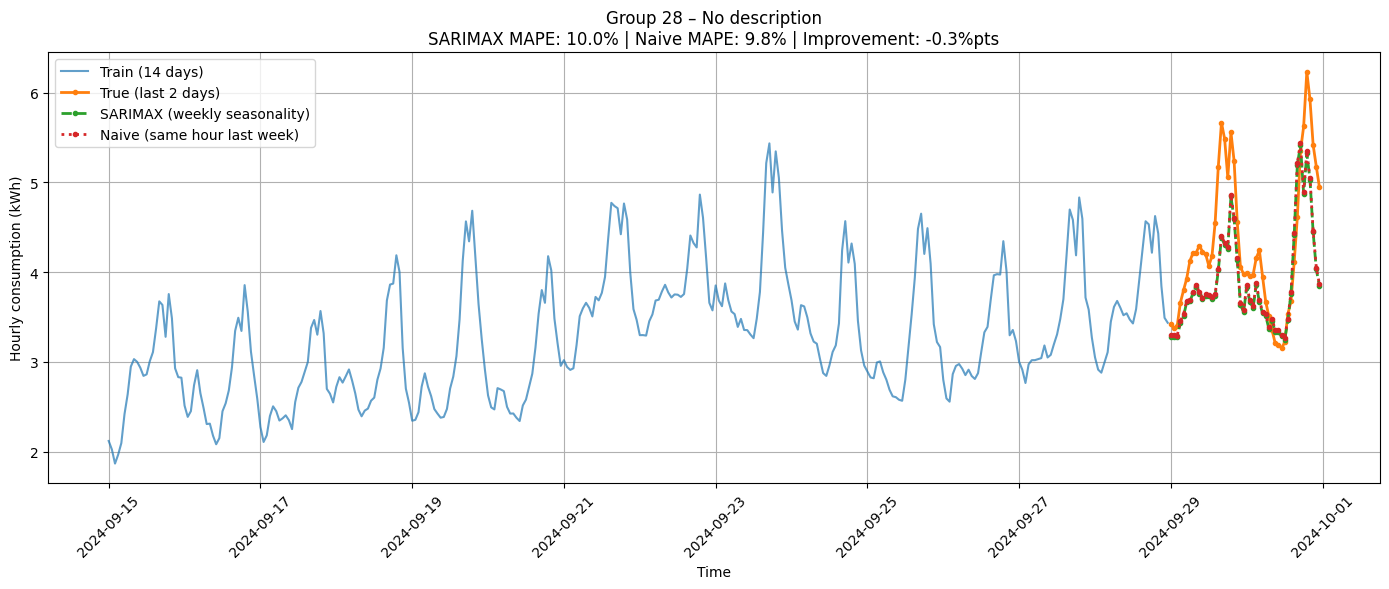

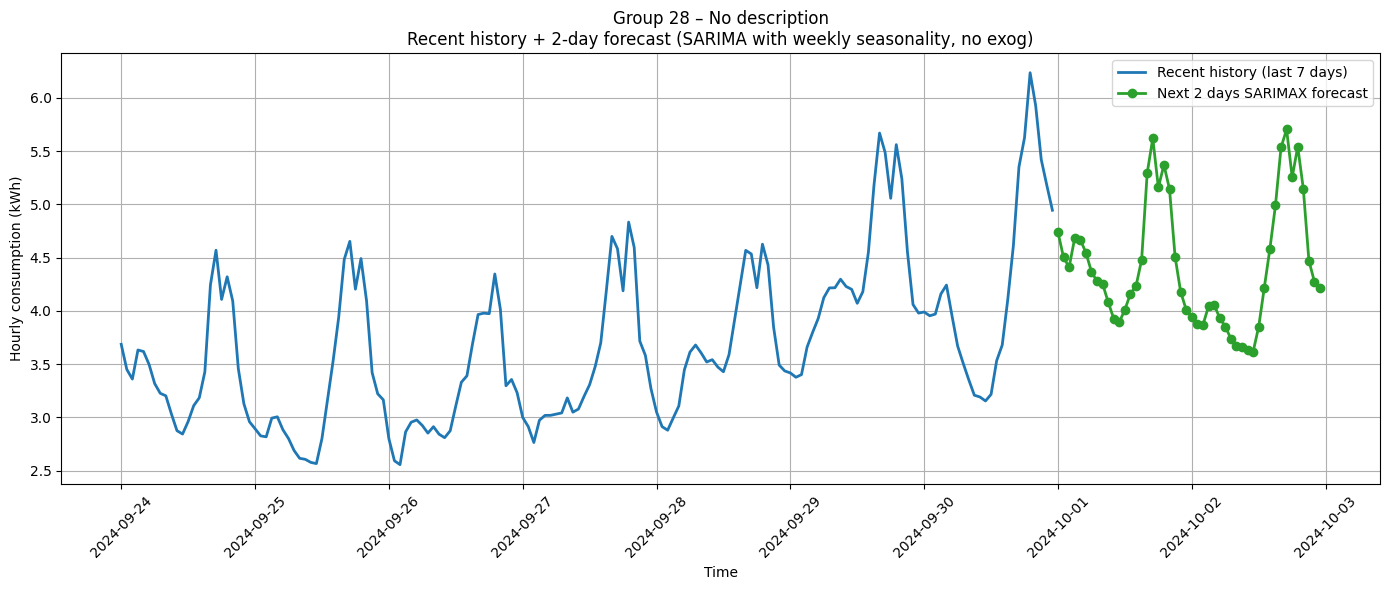

In [ ]:
# Choose a group to visualize
GROUP_ID = None  # Change this to any group ID you want to analyze
GROUP_INDEX = 0  # Or use index if you don't know the ID

AVAILABLE_GROUPS = list(df_cons.columns)
TARGET_GROUP_ID = str(GROUP_ID) if GROUP_ID is not None else AVAILABLE_GROUPS[GROUP_INDEX]
print("Visualizing group:", TARGET_GROUP_ID)

series = df_cons[TARGET_GROUP_ID].dropna()
bt = sarimax_backtest_2days(
    series,
    exog_df=None,  # No exog for better performance
    order=FIXED_ORDER,
    seasonal_order=FIXED_SEASONAL_ORDER,
    auto_tune=False,
    use_log=False,
    train_days=TRAIN_DAYS,
    use_exog=False
)

if bt is None:
    raise ValueError(f"Not enough history for this group. Need at least {TRAIN_DAYS+2} days.")

val_true, sarimax_val_forecast, naive_val_forecast, used_log = bt

# Get the training data for visualization
total_hours = (TRAIN_DAYS + 2) * 24
recent_data = series.iloc[-total_hours:]
train_hours = TRAIN_DAYS * 24
train_part = recent_data.iloc[:train_hours]
val_part = recent_data.iloc[train_hours:]

# Plot 1: Backtest results
plt.figure(figsize=(14, 6))

plt.plot(train_part.index, train_part.values,
         label=f"Train ({TRAIN_DAYS} days)", color="C0", alpha=0.7)
plt.plot(val_true.index, val_true.values,
         marker=".", linestyle="-", label="True (last 2 days)", color="C1", linewidth=2)
plt.plot(sarimax_val_forecast.index, sarimax_val_forecast.values,
         marker=".", linestyle="--", label="SARIMAX (weekly seasonality)", color="C2", linewidth=2)
plt.plot(naive_val_forecast.index, naive_val_forecast.values,
         marker=".", linestyle=":", label="Naive (same hour last week)", color="C3", linewidth=2)

desc = group_desc.get(TARGET_GROUP_ID, "No description")

# Calculate improvement
sarima_mape = mape(val_true, sarimax_val_forecast)
naive_mape = mape(val_true, naive_val_forecast)
improvement = naive_mape - sarima_mape

plt.title(
    f"Group {TARGET_GROUP_ID} – {desc}\n"
    f"SARIMAX MAPE: {sarima_mape:.1f}% | Naive MAPE: {naive_mape:.1f}% | Improvement: {improvement:+.1f}%pts"
)
plt.xlabel("Time")
plt.ylabel("Hourly consumption (kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: Full history + next 2 days forecast
if TARGET_GROUP_ID in future_forecasts:
    fut_forecast = future_forecasts[TARGET_GROUP_ID]

    # Show last 7 days of history + 2 days forecast for better visibility
    recent_history = series.iloc[-168:]  # Last 7 days = 168 hours

    plt.figure(figsize=(14, 6))
    plt.plot(recent_history.index, recent_history.values,
             label="Recent history (last 7 days)", color="C0", linewidth=2)
    plt.plot(fut_forecast.index, fut_forecast.values,
             marker="o", linestyle="-",
             label="Next 2 days SARIMAX forecast", color="C2", linewidth=2)

    plt.title(
        f"Group {TARGET_GROUP_ID} – {desc}\n"
        f"Recent history + 2-day forecast (SARIMA with weekly seasonality, no exog)"
    )

    plt.xlabel("Time")
    plt.ylabel("Hourly consumption (kWh)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print(f"No forecast available for group {TARGET_GROUP_ID}")